In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

rng = np.random.default_rng()

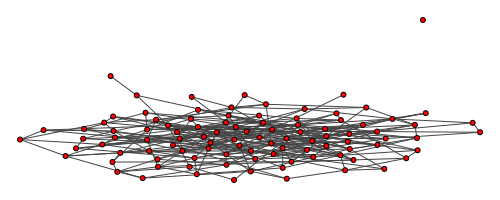

In [2]:
g = ig.Graph.Erdos_Renyi(n=100, p=0.05)
ig.plot(g, layout="graphopt", bbox=(500, 200), vertex_size=5)

In [2]:
g = ig.Graph.Lattice([10, 10], circular=False)
# ig.plot(g, layout="grid", bbox=(500, 200), vertex_size=5)

In [15]:
size, depth = 100, 1000
lcc = np.zeros(size, dtype="float32")
all_prob = np.linspace(0, 1, size)
for idx, prob in tqdm(enumerate(all_prob), total=size):
    is_removed = rng.random((depth, g.ecount()), dtype="float32")
    is_removed = is_removed >= prob
    for rep in range(depth):
        work = g.copy()
        links_to_remove = np.flatnonzero(is_removed[rep])
        work.delete_edges(links_to_remove)
        lcc[idx] += work.components().size(0)
        # try:
        #     slcc[idx] += work.components().size(1)
        # except IndexError:
        #     slcc[idx] += 0
    # slcc[idx] /= depth
    lcc[idx] /= depth

  0%|          | 0/100 [00:00<?, ?it/s]

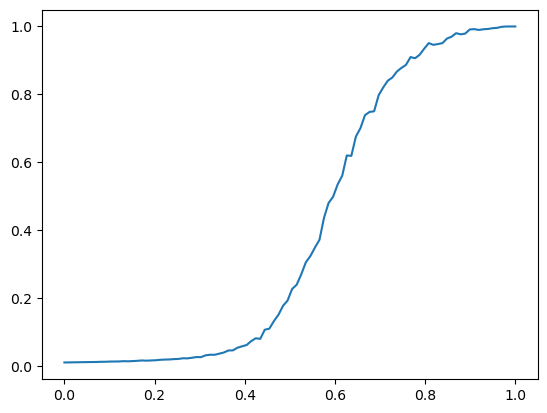

In [16]:
plt.plot(all_prob, lcc/g.vcount())